Date range: 2018-01-01 -> 2026-03-04
Universe size after dynamic eligibility screen: 35

TOP TRAIN SPECS (Ensemble): [(20, 60, 10), (20, 30, 10), (10, 30, 10)]


,spec,TrainSharpe,TrainAnnRet,TrainMaxDD,TrainTurnover
0,"(20, 60, 10)",1.472925,0.967508,-0.633947,0.076882
1,"(20, 30, 10)",1.402105,0.906293,-0.645044,0.083741
2,"(10, 30, 10)",1.109275,0.719806,-0.659862,0.108841
3,"(60, 60, 10)",1.076187,0.656986,-0.619742,0.054361
4,"(60, 30, 10)",0.953571,0.584979,-0.656213,0.058207


,Train,Test
AnnRet,0.244155,0.240566
AnnVol,0.208651,0.215412
Sharpe,1.170159,1.116771
Sortino,1.354029,1.610660
MaxDD,-0.315449,-0.252733
CVaR95,-0.026148,-0.024840
tStatMean,2.576003,1.568417
AlphaBTC,0.200280,-0.074295
BetaBTC,0.184816,0.321319
AlphaEW,0.185863,0.013200


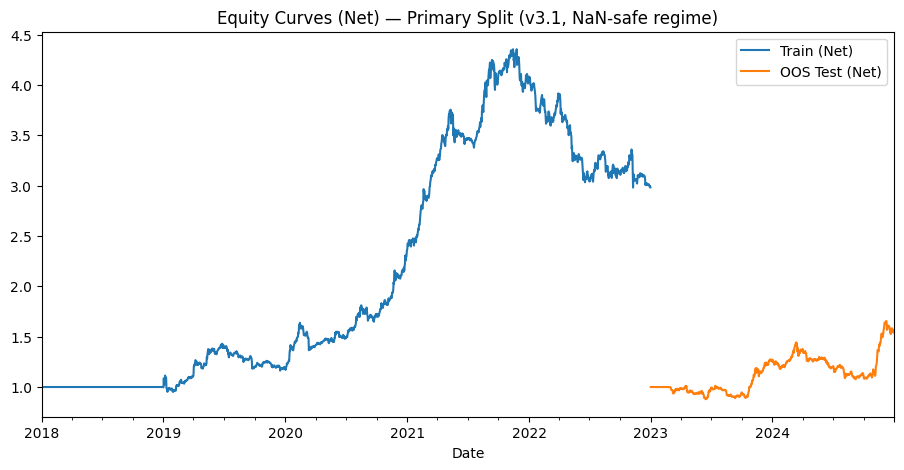

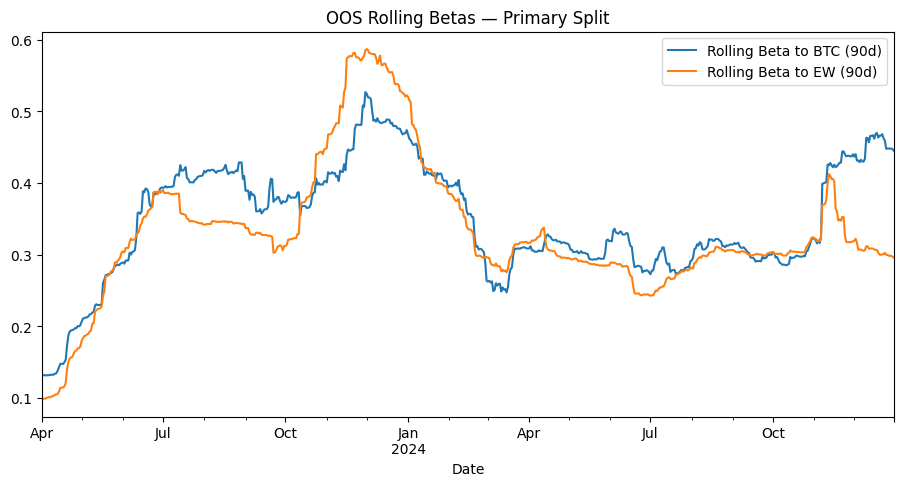


OOS cost diagnostics (Primary):


,turnover,impact_bps,total_bps,cost,leverage
count,731.000000,731.0,731.0,731.000000,731.000000
mean,0.058127,0.0,20.0,0.000116,0.417548
std,0.032090,0.0,0.0,0.000064,0.192933
min,0.000000,0.0,20.0,0.000000,0.000000
25%,0.042370,0.0,20.0,0.000085,0.336098
50%,0.056584,0.0,20.0,0.000113,0.411420
75%,0.073059,0.0,20.0,0.000146,0.498469
max,0.341687,0.0,20.0,0.000683,0.988017


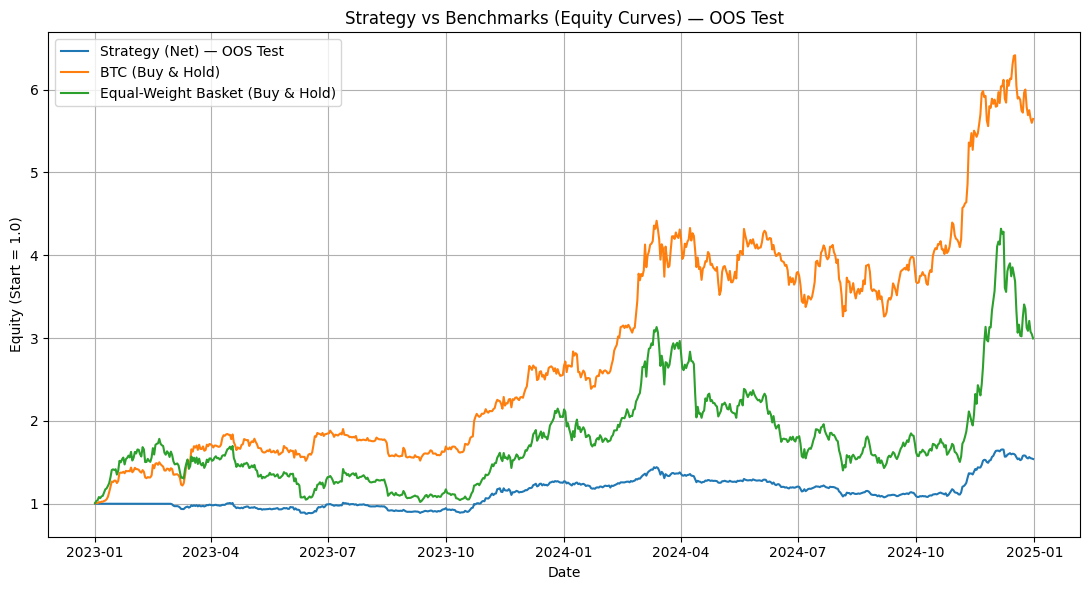

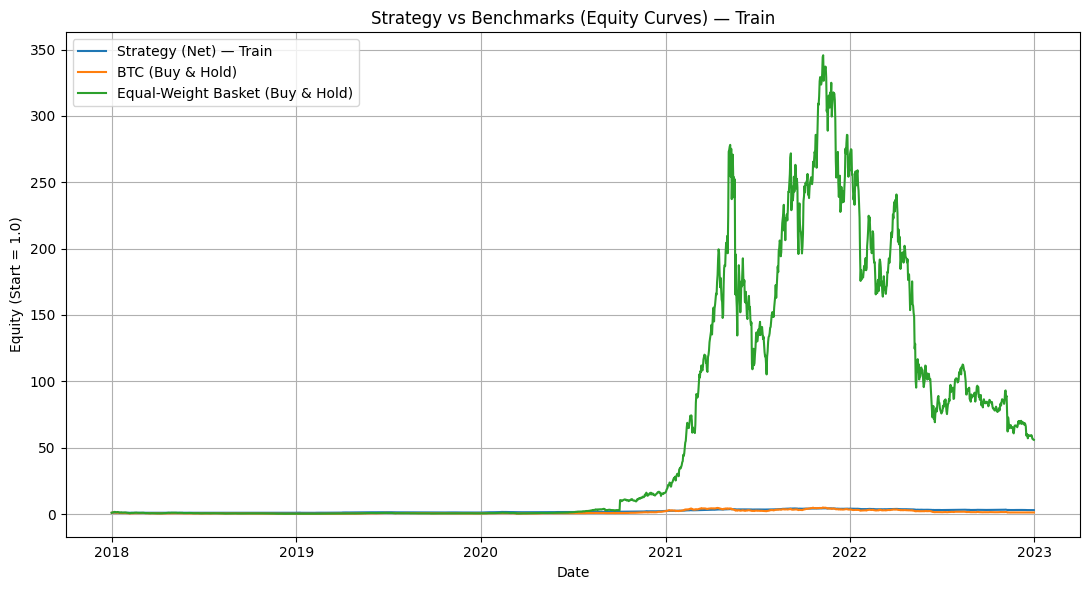


DONE.


In [11]:
# ============================================================
# Wall Street Quants Course Project (Daily):
# Cross-sectional momentum / relative strength strategy for cryptocurrencies
# Matias Arnal
#
# Requirements:
# - Multi-asset crypto universe (30+ cryptos)
# - Unconstrained backtests
# - Execution costs: 20 bps market-order assumption (7 bps commission + 13 bps slippage)
# - Train / OOS test split + walk-forward evaluation
# - Performance: returns, vol, Sharpe, max drawdown, alpha/beta
# 
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
import sys

try:
    from IPython.display import display
except Exception:
    display = print

PER_YEAR = 365
np.seterr(divide="ignore", invalid="ignore")

# -----------------------------
# 0) GLOBAL SETTINGS
# -----------------------------
START_DATE = "2018-01-01"
END_DATE   = None

PRIMARY_TRAIN_START = "2018-01-01"
PRIMARY_TRAIN_END   = "2022-12-31"
PRIMARY_TEST_START  = "2023-01-01"
PRIMARY_TEST_END    = "2024-12-31"

WF_TRAIN_START = "2018-01-01"
WF_OOS_YEARS   = ["2023", "2024"]

UNIV = [
    "BTC-USD","ETH-USD","BNB-USD","SOL-USD","XRP-USD","ADA-USD","DOGE-USD",
    "AVAX-USD","DOT-USD","MATIC-USD","LTC-USD","LINK-USD","BCH-USD","ATOM-USD",
    "XLM-USD","ETC-USD","ICP-USD","FIL-USD","TRX-USD","NEAR-USD","HBAR-USD",
    "AAVE-USD","SAND-USD","MANA-USD","ALGO-USD","VET-USD","EGLD-USD","XTZ-USD",
    "EOS-USD","ZEC-USD","KSM-USD","THETA-USD","FLOW-USD","XMR-USD","QNT-USD"
]

ADV_LOOKBACK = 60
MIN_MEDIAN_ADV = 5_000_000
MIN_PRICE_HISTORY_DAYS = 365

WINSOR_Z = 3.0

GRID = [
    (10, 30, 10),
    (20, 30, 10),
    (20, 60, 10),
    (60, 30, 10),
    (60, 60, 10),
]
ENSEMBLE_TOP_N = 3

USE_BTC_REGIME = True
BTC_MA = 200

BULL_TOPK_MULT = 1.00
BEAR_TOPK_MULT = 0.70

BULL_GROSS = 1.00
BEAR_GROSS = 0.50

BULL_W_MOM = 1.00
BULL_W_LOWVOL = 0.50

BEAR_W_MOM = 0.40
BEAR_W_LOWVOL = 1.20

USE_SOFTMAX = True
SOFTMAX_TAU = 1.0

INTRA_BASKET_INVVOL = True
INTRA_INVVOL_LOOKBACK = 30

WEIGHT_SMOOTH_ALPHA = 0.25

USE_VOL_TARGET = True
PORT_TARGET_VOL = 0.20
PORT_VOL_LOOKBACK = 60
MAX_LEVERAGE = 3.0

FIXED_COST_BPS = 20
IMPACT_K = 0
IMPACT_VOL_LOOKBACK = 20
IMPACT_ADV_LOOKBACK = 60

ENABLE_CONSTRAINTS = False
MAX_WEIGHT_PER_COIN = 0.12
MIN_WEIGHT_PER_COIN = 0.00
MAX_GROSS_EXPOSURE = 1.00
MAX_NAMES_HELD = None

ENABLE_EXPOSURE_LIMITS = False
TARGET_BTC_BETA = 0.00
MAX_ABS_BTC_BETA = 0.35
MAX_VOL_EXPOSURE = 0.75
VOL_EXPOSURE_LOOKBACK = 30

ENABLE_RISK_PARITY_REFINEMENT = False
RP_WINDOW = 30
RP_ITERS = 6

REPORT_IC = True
ATTRIBUTION = True

DO_BOOTSTRAP_FINAL = False
BOOTSTRAP_N = 800
BOOTSTRAP_SEED = 7
np.random.seed(BOOTSTRAP_SEED)


# ============================================================
# 1) DATA
# ============================================================
def download_crypto(tickers, start=START_DATE, end=END_DATE):
    data = yf.download(
        tickers=tickers, start=start, end=end,
        progress=False, group_by="ticker", auto_adjust=False
    )
    px = pd.DataFrame()
    vol = pd.DataFrame()

    if isinstance(data.columns, pd.MultiIndex):
        for t in tickers:
            if (t, "Adj Close") in data.columns:
                px[t] = data[(t, "Adj Close")]
            elif (t, "Close") in data.columns:
                px[t] = data[(t, "Close")]
            if (t, "Volume") in data.columns:
                vol[t] = data[(t, "Volume")]
    else:
        t = tickers[0]
        px[t] = data["Adj Close"] if "Adj Close" in data.columns else data["Close"]
        vol[t] = data.get("Volume", np.nan)

    px = px.sort_index().ffill()
    vol = vol.reindex(px.index).fillna(0.0)
    ret = px.pct_change()
    vol = vol.reindex(ret.index).fillna(0.0)
    return px, vol, ret


# ============================================================
# 2) ELIGIBILITY
# ============================================================
def rolling_median_adv(px_df, vol_df, lookback=ADV_LOOKBACK):
    adv = (px_df * vol_df).replace([np.inf, -np.inf], np.nan)
    return adv.rolling(lookback).median()

def dynamic_eligibility(px_df, vol_df,
                        adv_lookback=ADV_LOOKBACK,
                        min_adv=MIN_MEDIAN_ADV,
                        min_hist_days=MIN_PRICE_HISTORY_DAYS):
    adv_med = rolling_median_adv(px_df, vol_df, lookback=adv_lookback)
    hist_count = px_df.notna().expanding().sum()
    elig = (adv_med >= min_adv) & (hist_count >= min_hist_days)
    return elig.astype(float)


# ============================================================
# 3) METRICS
# ============================================================
def max_drawdown(eq):
    peak = eq.cummax()
    dd = eq / peak - 1
    return float(dd.min())

def ann_return(r):
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    return float((1 + r).prod() ** (PER_YEAR / len(r)) - 1)

def ann_vol(r):
    r = r.dropna()
    return float(r.std() * np.sqrt(PER_YEAR))

def sharpe(r):
    v = ann_vol(r)
    return np.nan if v == 0 or np.isnan(v) else ann_return(r) / v

def sortino(r):
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    downside = r[r < 0]
    dd = downside.std() * np.sqrt(PER_YEAR)
    ar = ann_return(r)
    return np.nan if dd == 0 or np.isnan(dd) else ar / dd

def cvar(r, alpha=0.95):
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    q = np.quantile(r, 1 - alpha)
    tail = r[r <= q]
    return float(tail.mean()) if len(tail) else float(q)

def tstat_mean(r):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    mu = r.mean()
    se = r.std(ddof=1) / np.sqrt(len(r))
    return np.nan if se == 0 else float(mu / se)

def alpha_beta(port_ret, bench_ret):
    df = pd.concat([port_ret, bench_ret], axis=1).dropna()
    if df.shape[0] < 60:
        return (np.nan, np.nan)
    y = df.iloc[:, 0]
    x = sm.add_constant(df.iloc[:, 1])
    res = sm.OLS(y, x).fit()
    a = res.params["const"]
    b = res.params[df.columns[1]]
    alpha_ann = (1 + a) ** PER_YEAR - 1
    return (float(alpha_ann), float(b))

def rolling_beta(port_ret, bench_ret, window=90):
    df = pd.concat([port_ret, bench_ret], axis=1).dropna()
    if df.shape[0] < window + 5:
        return pd.Series(index=port_ret.index, dtype=float)
    y = df.iloc[:, 0]
    x = df.iloc[:, 1]
    betas = []
    idx = df.index
    for i in range(window, len(df)):
        yy = y.iloc[i-window:i]
        xx = sm.add_constant(x.iloc[i-window:i])
        b = sm.OLS(yy, xx).fit().params[x.name]
        betas.append(b)
    return pd.Series(betas, index=idx[window:])

def summarize(bt, btc_ret, ew_ret, label=""):
    r = bt["net"].dropna()
    eq = (1 + r).cumprod()

    a_btc, b_btc = alpha_beta(bt["net"], btc_ret)
    a_ew, b_ew   = alpha_beta(bt["net"], ew_ret)

    return pd.Series({
        "AnnRet": ann_return(bt["net"]),
        "AnnVol": ann_vol(bt["net"]),
        "Sharpe": sharpe(bt["net"]),
        "Sortino": sortino(bt["net"]),
        "MaxDD": max_drawdown(eq),
        "CVaR95": cvar(bt["net"], 0.95),
        "tStatMean": tstat_mean(bt["net"]),
        "AlphaBTC": a_btc,
        "BetaBTC": b_btc,
        "AlphaEW": a_ew,
        "BetaEW": b_ew,
        "AvgTurnover": float(bt["turnover"].mean()),
        "AvgCost": float(bt["cost"].mean()),
        "AvgTotalBps": float(bt["total_bps"].mean()),
        "AvgLeverage": float(bt["leverage"].mean()),
    }, name=label)


# ============================================================
# 4) FACTORS + CS HELPERS
# ============================================================
def rolling_compound_return(r, lookback):
    return (1 + r).rolling(lookback).apply(np.prod, raw=True) - 1

def rolling_vol(r, lookback):
    return r.rolling(lookback).std() * np.sqrt(PER_YEAR)

def cs_zscore(df, winsor=WINSOR_Z):
    mu = df.mean(axis=1)
    sd = df.std(axis=1, ddof=0).replace(0, np.nan)
    z = df.sub(mu, axis=0).div(sd, axis=0).fillna(0.0)
    if winsor is not None:
        z = z.clip(-winsor, winsor)
    return z

def asset_beta_to_btc(ret_df, btc_ret, window=90):
    rb = btc_ret
    varb = rb.rolling(window).var()
    betas = {}
    for c in ret_df.columns:
        cov = ret_df[c].rolling(window).cov(rb)
        betas[c] = (cov / varb).replace([np.inf, -np.inf], np.nan)
    return pd.DataFrame(betas).reindex(ret_df.index)

def neutralize_cross_section(signal, exposures_dict, elig_row):
    assets = signal.index
    m = elig_row.reindex(assets).fillna(0.0) > 0
    s = signal.where(m).dropna()
    if len(s) < 8:
        return signal * 0.0

    X_cols = []
    for _, ex in exposures_dict.items():
        X_cols.append(ex.reindex(s.index).astype(float))
    X = np.column_stack([np.ones(len(s))] + X_cols)
    y = s.values.astype(float)

    try:
        b, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        yhat = X @ b
        resid = y - yhat
        out = pd.Series(0.0, index=assets)
        out.loc[s.index] = resid
        return out
    except Exception:
        return signal * 0.0


# ============================================================
# 5) ### FIX: NaN-safe regime
# ============================================================
def btc_regime_strength(btc_ret, ma=BTC_MA):
    btc_ret = btc_ret.copy()
    btc_px = (1 + btc_ret.fillna(0)).cumprod()
    ma_series = btc_px.rolling(ma).mean()
    raw = (btc_px / ma_series - 1.0).replace([np.inf, -np.inf], np.nan)
    raw = raw.clip(-0.25, 0.25) / 0.25
    # shift to avoid lookahead
    out = raw.fillna(0.0).shift(1)
    return out

def _safe_float(x, default=0.0):
    try:
        v = float(x)
        if np.isfinite(v):
            return v
        return float(default)
    except Exception:
        return float(default)

def regime_params(strength):
    # Ensure strength is finite
    s = _safe_float(strength, 0.0)
    s = float(np.clip(s, -1.0, 1.0))

    w_mom    = BEAR_W_MOM    + (BULL_W_MOM    - BEAR_W_MOM)    * (s + 1) / 2
    w_lowvol = BEAR_W_LOWVOL + (BULL_W_LOWVOL - BEAR_W_LOWVOL) * (s + 1) / 2
    gross    = BEAR_GROSS    + (BULL_GROSS    - BEAR_GROSS)    * (s + 1) / 2
    topk_mul = BEAR_TOPK_MULT + (BULL_TOPK_MULT - BEAR_TOPK_MULT) * (s + 1) / 2

    # Final clamp to avoid NaNs / nonsense
    w_mom = _safe_float(w_mom, 1.0)
    w_lowvol = _safe_float(w_lowvol, 1.0)
    gross = float(np.clip(_safe_float(gross, 1.0), 0.0, MAX_GROSS_EXPOSURE))
    topk_mul = float(np.clip(_safe_float(topk_mul, 1.0), 0.25, 2.0))
    return w_mom, w_lowvol, gross, topk_mul


# ============================================================
# 6) EXPOSURE PROJECTION
# ============================================================
def apply_hard_constraints(w, elig_row,
                           max_w=MAX_WEIGHT_PER_COIN,
                           min_w=MIN_WEIGHT_PER_COIN,
                           max_gross=MAX_GROSS_EXPOSURE,
                           max_names=MAX_NAMES_HELD):
    w = w.copy()
    w = w.where(elig_row > 0, 0.0)

    if max_names is not None:
        nonzero = w[w > 0].sort_values(ascending=False)
        keep = nonzero.index[:max_names]
        w.loc[~w.index.isin(keep)] = 0.0

    w = w.clip(lower=min_w, upper=max_w)
    w = w.where(elig_row > 0, 0.0)

    g = float(w.abs().sum())
    if g > 0:
        w = w * (min(max_gross, g) / g)
    return w

def project_beta_cap(w, beta_vec, target=TARGET_BTC_BETA, cap=MAX_ABS_BTC_BETA):
    w = w.copy()
    b = beta_vec.fillna(0.0)

    port_beta = float((w * b).sum())
    if not np.isfinite(port_beta):
        return w

    if abs(port_beta - target) <= cap:
        return w

    denom = float((b * b).sum()) + 1e-12
    k = (port_beta - target) / denom
    w2 = w - k * b
    return w2.clip(lower=0.0)

def project_vol_exposure_cap(w, vol_exposure_vec, cap=MAX_VOL_EXPOSURE):
    w = w.copy()
    v = vol_exposure_vec.fillna(0.0).clip(lower=0.0)
    gross = float(w.abs().sum()) + 1e-12
    exposure = float((w * v).sum()) / gross

    if not np.isfinite(exposure) or exposure <= cap:
        return w

    lam = (exposure / cap) - 1.0
    scale = 1.0 / (1.0 + lam * v)
    return w * scale


# ============================================================
# 7) SIGNALS + WEIGHTS
# ============================================================
def softmax_weights(scores, tau=1.0):
    s = scores / max(tau, 1e-6)
    s = s - np.nanmax(s)
    e = np.exp(s)
    es = np.nansum(e)
    if not np.isfinite(es) or es == 0:
        return e * 0.0
    return e / es

def build_signal_one_spec(ret_df, elig_df, btc_strength,
                          mom_lb, vol_lb,
                          beta_df, vol_ann_df):
    mom = rolling_compound_return(ret_df, mom_lb).where(elig_df > 0, np.nan)
    vol_ann = rolling_vol(ret_df, vol_lb).where(elig_df > 0, np.nan)
    mom_z = cs_zscore(mom)
    vol_z = cs_zscore(vol_ann)

    sig = pd.DataFrame(0.0, index=ret_df.index, columns=ret_df.columns)

    # Align strength (IMPORTANT)
    btc_strength = btc_strength.reindex(ret_df.index).fillna(0.0)

    for t in ret_df.index:
        strength = btc_strength.loc[t]
        w_mom, w_lowvol, _, _ = regime_params(strength)
        raw = w_mom * mom_z.loc[t] + w_lowvol * (-vol_z.loc[t])

        exposures = {"beta": beta_df.loc[t], "vol": vol_ann_df.loc[t]}
        n = neutralize_cross_section(raw, exposures, elig_df.loc[t])
        sig.loc[t] = n
    return sig

def make_weights_from_signal(signal_df, ret_df, elig_df, btc_strength,
                             topk_base,
                             invvol=True, invvol_lb=INTRA_INVVOL_LOOKBACK,
                             use_softmax=USE_SOFTMAX, tau=SOFTMAX_TAU,
                             smooth_alpha=WEIGHT_SMOOTH_ALPHA,
                             beta_df=None, vol_exposure_df=None):
    rv_daily = ret_df.rolling(invvol_lb).std() if invvol else None

    W = pd.DataFrame(0.0, index=ret_df.index, columns=ret_df.columns)
    prev = pd.Series(0.0, index=ret_df.columns)

    # Align strength (IMPORTANT)
    btc_strength = btc_strength.reindex(ret_df.index).fillna(0.0)

    for t in ret_df.index:
        strength = btc_strength.loc[t]
        _, _, gross, topk_mult = regime_params(strength)

        # --------- FIX: topk_mult always finite now ----------
        top_k = int(max(3, round(float(topk_base) * float(topk_mult))))

        s = signal_df.loc[t].where(elig_df.loc[t] > 0, np.nan).dropna()
        if len(s) < top_k:
            new = prev * (1 - smooth_alpha)
            W.loc[t] = new
            prev = new
            continue

        top = s.sort_values(ascending=False).iloc[:top_k]

        if use_softmax:
            w_raw = pd.Series(softmax_weights(top.values, tau=tau), index=top.index)
        else:
            w_raw = pd.Series(1.0 / top_k, index=top.index)

        if invvol:
            v = rv_daily.loc[t, top.index].replace(0, np.nan)
            inv = (1.0 / v).replace([np.inf, -np.inf], np.nan).fillna(0.0)
            w_raw = w_raw * inv
            if w_raw.sum() > 0:
                w_raw = w_raw / w_raw.sum()

        w_raw = w_raw * gross

        target = pd.Series(0.0, index=ret_df.columns)
        target.loc[w_raw.index] = w_raw

        new = (1 - smooth_alpha) * prev + smooth_alpha * target
        new = new.where(elig_df.loc[t] > 0, 0.0)

        if ENABLE_EXPOSURE_LIMITS and beta_df is not None:
            new = project_beta_cap(new, beta_df.loc[t], target=TARGET_BTC_BETA, cap=MAX_ABS_BTC_BETA)
            if vol_exposure_df is not None:
                new = project_vol_exposure_cap(new, vol_exposure_df.loc[t], cap=MAX_VOL_EXPOSURE)

        if ENABLE_CONSTRAINTS:
            new = apply_hard_constraints(
                new, elig_df.loc[t],
                max_w=MAX_WEIGHT_PER_COIN,
                min_w=MIN_WEIGHT_PER_COIN,
                max_gross=MAX_GROSS_EXPOSURE,
                max_names=MAX_NAMES_HELD
            )

        g = float(new.abs().sum())
        desired = min(gross, MAX_GROSS_EXPOSURE)
        if g > 0 and desired > 0:
            new = new * (desired / g)

        W.loc[t] = new
        prev = new

    return W.shift(1).fillna(0.0)

def ensemble_weights(ret_df, elig_df, btc_strength,
                     specs, beta_df, vol_exposure_df):
    sigs = []
    for mom_lb, vol_lb, topk in specs:
        sig = build_signal_one_spec(ret_df, elig_df, btc_strength, mom_lb, vol_lb, beta_df, vol_exposure_df)
        sigs.append(sig)

    sig_ens = sum(sigs) / len(sigs)
    topk_base = int(np.median([s[2] for s in specs]))

    W = make_weights_from_signal(
        sig_ens, ret_df, elig_df, btc_strength,
        topk_base=topk_base,
        beta_df=beta_df,
        vol_exposure_df=vol_exposure_df
    )

    return W, sig_ens


# ============================================================
# 8) COSTS + BACKTEST
# ============================================================
def compute_impact_bps_series(ret_df, px_df, vol_df, w_scaled,
                              vol_lb=IMPACT_VOL_LOOKBACK,
                              adv_lb=IMPACT_ADV_LOOKBACK,
                              k=IMPACT_K):
    sigma = ret_df.rolling(vol_lb).std()
    adv = (px_df * vol_df).rolling(adv_lb).median().replace(0, np.nan)

    dw = (w_scaled - w_scaled.shift(1)).abs()
    impact_term = (sigma / np.sqrt(adv)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    num = (dw * impact_term).sum(axis=1)
    den = dw.sum(axis=1).replace(0, np.nan)
    avg_impact = (num / den).fillna(0.0)

    return (k * avg_impact * 1e4).astype(float)

def backtest(ret_df, px_df, vol_df, w_target,
             fixed_cost_bps=FIXED_COST_BPS,
             use_vol_target=USE_VOL_TARGET,
             target_vol=PORT_TARGET_VOL,
             port_vol_lb=PORT_VOL_LOOKBACK,
             max_leverage=MAX_LEVERAGE):

    w = w_target.reindex(ret_df.index).fillna(0.0)
    w = w[ret_df.columns].fillna(0.0)

    if use_vol_target:
        gross_base = (w.shift(1) * ret_df).sum(axis=1)
        port_rv = gross_base.rolling(port_vol_lb).std() * np.sqrt(PER_YEAR)
        L = (target_vol / port_rv).clip(lower=0.0, upper=max_leverage).fillna(0.0)
        w_scaled = w.mul(L, axis=0)
    else:
        L = pd.Series(1.0, index=w.index)
        w_scaled = w

    gross = (w_scaled.shift(1) * ret_df).sum(axis=1)
    turnover = (w_scaled - w_scaled.shift(1)).abs().sum(axis=1).fillna(0.0)

    impact_bps = compute_impact_bps_series(ret_df, px_df, vol_df, w_scaled)
    total_bps = fixed_cost_bps + impact_bps
    cost = (total_bps / 10000.0) * turnover
    net = gross - cost

    out = pd.DataFrame({
        "gross": gross,
        "net": net,
        "turnover": turnover,
        "impact_bps": impact_bps,
        "total_bps": total_bps,
        "cost": cost,
        "leverage": L
    })
    return out, w_scaled


# ============================================================
# 9) TRAIN SELECTION + RUN SPLIT
# ============================================================
def train_select_top_specs(ret_tr, px_tr, vol_tr, elig_tr, btc_tr, grid=GRID, top_n=ENSEMBLE_TOP_N):
    btc_strength_tr = btc_regime_strength(btc_tr, BTC_MA) if USE_BTC_REGIME else pd.Series(0.0, index=ret_tr.index)
    btc_strength_tr = btc_strength_tr.reindex(ret_tr.index).fillna(0.0)

    beta_tr = asset_beta_to_btc(ret_tr, btc_tr, window=90).fillna(0.0)
    vol_exp_tr = rolling_vol(ret_tr, lookback=VOL_EXPOSURE_LOOKBACK).fillna(0.0)

    rows = []
    for mom_lb, vol_lb, topk in grid:
        sig = build_signal_one_spec(ret_tr, elig_tr, btc_strength_tr, mom_lb, vol_lb, beta_tr, vol_exp_tr)
        W = make_weights_from_signal(sig, ret_tr, elig_tr, btc_strength_tr, topk_base=topk,
                                     beta_df=beta_tr, vol_exposure_df=vol_exp_tr)

        bt_tr, _ = backtest(ret_tr, px_tr, vol_tr, W, fixed_cost_bps=FIXED_COST_BPS, use_vol_target=False)

        rows.append({
            "spec": (mom_lb, vol_lb, topk),
            "TrainSharpe": sharpe(bt_tr["net"]),
            "TrainAnnRet": ann_return(bt_tr["net"]),
            "TrainMaxDD": max_drawdown((1 + bt_tr["net"].fillna(0)).cumprod()),
            "TrainTurnover": float(bt_tr["turnover"].mean()),
        })

    df = pd.DataFrame(rows).sort_values("TrainSharpe", ascending=False).reset_index(drop=True)
    return df, df["spec"].iloc[:top_n].tolist()

def run_split(ret_df, px_df, vol_df, elig_df, train_start, train_end, test_start, test_end, do_bootstrap_final=False):
    if "BTC-USD" not in ret_df.columns:
        raise ValueError("BTC-USD must be in the universe for regime/beta logic. Add BTC-USD to UNIV.")

    btc = ret_df["BTC-USD"]
    ew = ret_df.mean(axis=1)

    tr = ret_df.loc[train_start:train_end]
    tr_px = px_df.loc[train_start:train_end]
    tr_vol = vol_df.loc[train_start:train_end]
    tr_elig = elig_df.loc[train_start:train_end]
    btc_tr = btc.loc[train_start:train_end]
    ew_tr  = ew.loc[train_start:train_end]

    te = ret_df.loc[test_start:test_end]
    te_px = px_df.loc[test_start:test_end]
    te_vol = vol_df.loc[test_start:test_end]
    te_elig = elig_df.loc[test_start:test_end]
    btc_te = btc.loc[test_start:test_end]
    ew_te  = ew.loc[test_start:test_end]

    grid_results, top_specs = train_select_top_specs(tr, tr_px, tr_vol, tr_elig, btc_tr)

    beta_full = asset_beta_to_btc(ret_df, btc, window=90).fillna(0.0)
    vol_exp_full = rolling_vol(ret_df, lookback=VOL_EXPOSURE_LOOKBACK).fillna(0.0)

    btc_strength_full = btc_regime_strength(btc, BTC_MA) if USE_BTC_REGIME else pd.Series(0.0, index=ret_df.index)
    btc_strength_full = btc_strength_full.reindex(ret_df.index).fillna(0.0)

    W_full, sig_full = ensemble_weights(ret_df, elig_df, btc_strength_full, top_specs, beta_full, vol_exp_full)

    W_tr = W_full.loc[train_start:train_end]
    W_te = W_full.loc[test_start:test_end]

    bt_tr, _ = backtest(tr, tr_px, tr_vol, W_tr, fixed_cost_bps=FIXED_COST_BPS,
                        use_vol_target=USE_VOL_TARGET, target_vol=PORT_TARGET_VOL,
                        port_vol_lb=PORT_VOL_LOOKBACK, max_leverage=MAX_LEVERAGE)
    bt_te, _ = backtest(te, te_px, te_vol, W_te, fixed_cost_bps=FIXED_COST_BPS,
                        use_vol_target=USE_VOL_TARGET, target_vol=PORT_TARGET_VOL,
                        port_vol_lb=PORT_VOL_LOOKBACK, max_leverage=MAX_LEVERAGE)

    summary = pd.DataFrame({
        "Train": summarize(bt_tr, btc_tr, ew_tr, label="TRAIN_FINAL"),
        "Test":  summarize(bt_te, btc_te, ew_te, label="TEST_OOS"),
    })

    return {
        "grid_results": grid_results,
        "top_specs": top_specs,
        "weights_full": W_full,
        "signal_full": sig_full,
        "bt_train": bt_tr,
        "bt_test": bt_te,
        "btc_train": btc_tr,
        "btc_test": btc_te,
        "ew_train": ew_tr,
        "ew_test": ew_te,
        "summary": summary
    }


# ============================================================
# 10) RUN
# ============================================================
px, vol, ret = download_crypto(UNIV, start=START_DATE, end=END_DATE)
print("Date range:", ret.index.min().date(), "->", ret.index.max().date())

elig = dynamic_eligibility(px, vol)
keep = elig.sum().loc[lambda s: s > 0].index.tolist()

px, vol, ret, elig = px[keep], vol[keep], ret[keep], elig[keep].reindex(ret.index).fillna(0.0)
print("Universe size after dynamic eligibility screen:", len(keep))

primary = run_split(
    ret, px, vol, elig,
    train_start=PRIMARY_TRAIN_START,
    train_end=PRIMARY_TRAIN_END,
    test_start=PRIMARY_TEST_START,
    test_end=PRIMARY_TEST_END,
    do_bootstrap_final=DO_BOOTSTRAP_FINAL
)

print("\nTOP TRAIN SPECS (Ensemble):", primary["top_specs"])
display(primary["grid_results"])
display(primary["summary"])

plt.figure()
((1 + primary["bt_train"]["net"].fillna(0)).cumprod()).plot(label="Train (Net)")
((1 + primary["bt_test"]["net"].fillna(0)).cumprod()).plot(label="OOS Test (Net)")
plt.title("Equity Curves (Net) — Primary Split (v3.1, NaN-safe regime)")
plt.legend()
plt.show()

oos_beta_btc = rolling_beta(primary["bt_test"]["net"], primary["btc_test"].rename("BTC"), window=90)
oos_beta_ew  = rolling_beta(primary["bt_test"]["net"], primary["ew_test"].rename("EW"), window=90)

plt.figure()
oos_beta_btc.plot(label="Rolling Beta to BTC (90d)")
oos_beta_ew.plot(label="Rolling Beta to EW (90d)")
plt.title("OOS Rolling Betas — Primary Split")
plt.legend()
plt.show()

print("\nOOS cost diagnostics (Primary):")
display(primary["bt_test"][["turnover","impact_bps","total_bps","cost","leverage"]].describe())

# ============================================================
# 10) ADDITIONAL GRAPHS
# ============================================================

def plot_strategy_vs_benchmarks(primary_result: dict,
                                btc_ret: pd.Series,
                                ew_ret: pd.Series,
                                which: str = "test",
                                title_suffix: str = ""):
    """
    Plots equity curves (start=1) for:
      - Strategy (Net)
      - BTC buy&hold
      - EW basket buy&hold
    """
    if which.lower() in ("test", "oos", "validation"):
        if "bt_test" in primary_result:
            strat_net = primary_result["bt_test"]["net"].copy()
            label_period = "OOS Test"
        elif "bt_oos" in primary_result:
            strat_net = primary_result["bt_oos"]["net"].copy()
            label_period = "OOS Test"
        else:
            raise KeyError("Expected primary_result['bt_test'] (or ['bt_oos']).")
    else:
        if "bt_train" in primary_result:
            strat_net = primary_result["bt_train"]["net"].copy()
            label_period = "Train"
        else:
            raise KeyError("Expected primary_result['bt_train'].")

    idx = strat_net.index
    btc_al = btc_ret.reindex(idx).fillna(0.0)
    ew_al  = ew_ret.reindex(idx).fillna(0.0)
    strat_al = strat_net.reindex(idx).fillna(0.0)

    eq_strat = eq_curve(strat_al)
    eq_btc   = eq_curve(btc_al)
    eq_ew    = eq_curve(ew_al)

    plt.figure(figsize=(11,6))
    plt.plot(eq_strat.index, eq_strat.values, label=f"Strategy (Net) — {label_period}")
    plt.plot(eq_btc.index,   eq_btc.values,   label="BTC (Buy & Hold)")
    plt.plot(eq_ew.index,    eq_ew.values,    label="Equal-Weight Basket (Buy & Hold)")
    plt.title(f"Strategy vs Benchmarks (Equity Curves) — {label_period}{title_suffix}")
    plt.xlabel("Date"); plt.ylabel("Equity (Start = 1.0)")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

# Plot for OOS/Test and Train window
plot_strategy_vs_benchmarks(primary, btc_ret=btc, ew_ret=ew, which="test")
plot_strategy_vs_benchmarks(primary, btc_ret=btc, ew_ret=ew, which="train")

print("\nDONE.")